# Primera comparación de modelos locales

Primera comparación de ocho configuraciones locales con dos jueces automáticos.

Este notebook solo lee resultados guardados. Ejecutar todas las celdas no descarga modelos, no consulta servicios y no sobrescribe las mediciones.

## Método y alcance

Son 18 pruebas, tres repeticiones y 432 respuestas evaluadas por dos jueces, `aya-expanse:8b` y `mistral-nemo:12b`. El hardware registrado es una RTX 4070 SUPER de 12 GB. Los tokens/s son la media por modelo.

La fidelidad es la media de las notas consolidadas de los jueces, entre 0 y 1. No adversarial corresponde al grupo llamado fácil en el informe original. No equivale a validación humana. Se conservan los votos y respuestas completos. El campo histórico `ttft` mide `prompt_eval_duration` de Ollama. Se presenta como tiempo de procesamiento del prompt, no como latencia observada hasta el primer token. La estabilidad mide la proporción de preguntas con el mismo veredicto en todas sus repeticiones.

In [1]:
import json
import sys
from pathlib import Path
from collections import defaultdict
from statistics import mean, median


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


def fidelity(verdicts: list[dict], *, adversarial: bool) -> float:
    values = [row["nota"] for row in verdicts if row["es_adversarial"] == adversarial]
    return round(mean(values), 3)


def stability(verdicts: list[dict]) -> float:
    by_question = defaultdict(set)
    for row in verdicts:
        by_question[row["prueba_id"]].add(row["veredicto"])
    return round(sum(len(values) == 1 for values in by_question.values()) / len(by_question), 3)


def summarize(data: dict) -> list[dict]:
    """Conserva los veredictos consolidados de la ejecución original."""
    rows = []
    for model in data["modelos"]:
        answers = data["respuestas"][model]
        verdicts = data["consolidados"][model]
        names = [row["veredicto"] for row in verdicts]
        rows.append(
            {
                "label": model,
                "easy": fidelity(verdicts, adversarial=False),
                "adversarial": fidelity(verdicts, adversarial=True),
                "hallucinations": names.count("ALUCINADA"),
                "language": names.count("IDIOMA_INCORRECTO"),
                "disagreements": names.count("DISCREPA"),
                "unanimity": data["acuerdo_inter_juez"]["por_modelo"][model],
                "stability": stability(verdicts),
                "vram": data["info"][model]["vram_gb"],
                "tps": round(mean(row["tps"] for row in answers), 1),
                "prompt_ms": round(median(row["ttft"] for row in answers), 1),
                "responses": len(answers),
            }
        )
    return rows


relative = Path("llm/comparison/archive")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Resultados guardados de", relative.as_posix(), "cargados")

rows = summarize(data)

[*] Resultados guardados de llm/comparison/archive cargados.


## Resultados

Los JSON conservan las mediciones originales.

### Calidad

In [2]:
show_table(
    rows,
    {
        "label": "Modelo",
        "easy": "Fid. no adv.",
        "adversarial": "Fid. adv.",
        "hallucinations": "Aluc.",
        "language": "Idioma",
        "disagreements": "Discrepa",
        "unanimity": "Acuerdo",
    },
)

| Modelo         | Fid. no adv.   | Fid. adv.   | Aluc.   | Idioma   | Discrepa   | Acuerdo   |
|----------------|----------------|-------------|---------|----------|------------|-----------|
| llama3.1:8b-Q4 | 1              | 0.667       | 0       | 0        | 2          | 0.963     |
| llama3.1:8b-Q5 | 1              | 0.583       | 0       | 0        | 0          | 1         |
| llama3.1:8b-Q6 | 1              | 0.604       | 0       | 0        | 1          | 0.981     |
| llama3.1:8b-Q8 | 1              | 0.625       | 0       | 0        | 0          | 1         |
| gemma4:e4b     | 1              | 0.812       | 0       | 0        | 9          | 0.833     |
| gemma3:12b     | 1              | 0.812       | 0       | 0        | 3          | 0.944     |
| phi4:14b       | 1              | 0.938       | 0       | 0        | 1          | 0.981     |
| qwen3:14b      | 1              | 0.771       | 0       | 0        | 7          | 0.87      |

### Recursos

In [3]:
show_table(
    rows,
    {
        "label": "Modelo",
        "vram": "VRAM GB",
        "tps": "Tokens/s",
        "prompt_ms": "Prompt p50 ms",
        "stability": "Estabilidad",
    },
)

| Modelo         | VRAM GB   | Tokens/s   | Prompt p50 ms   | Estabilidad   |
|----------------|-----------|------------|-----------------|---------------|
| llama3.1:8b-Q4 | 5.09      | 52.3       | 27.4            | 0.889         |
| llama3.1:8b-Q5 | 5.78      | 44.9       | 34              | 0.944         |
| llama3.1:8b-Q6 | 6.52      | 40.8       | 38.4            | 0.944         |
| llama3.1:8b-Q8 | 8.07      | 26.6       | 56.9            | 1             |
| gemma4:e4b     | 3.19      | 38.1       | 44.8            | 1             |
| gemma3:12b     | 9.26      | 32.5       | 45.2            | 1             |
| phi4:14b       | 8.62      | 24.7       | 63.2            | 0.944         |
| qwen3:14b      | 9.44      | 44.3       | 50.2            | 0.944         |

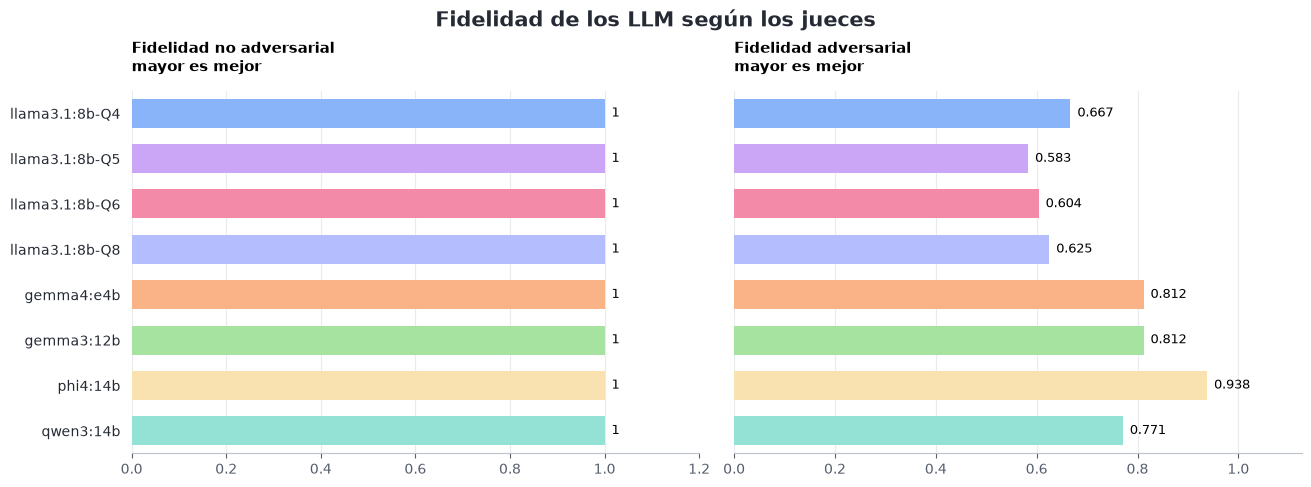

In [4]:
figure_0 = plot_metrics(
    rows,
    [
        ("easy", "Fidelidad no adversarial\nmayor es mejor"),
        ("adversarial", "Fidelidad adversarial\nmayor es mejor"),
    ],
    "Fidelidad de los LLM según los jueces",
)
figure_0

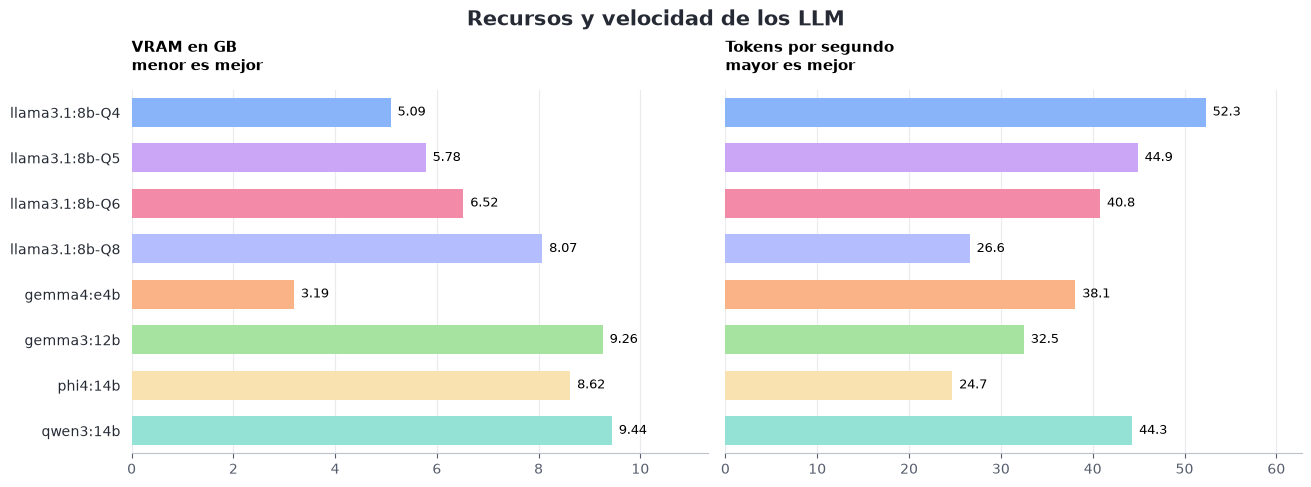

In [5]:
figure_1 = plot_metrics(
    rows,
    [("vram", "VRAM en GB\nmenor es mejor"), ("tps", "Tokens por segundo\nmayor es mejor")],
    "Recursos y velocidad de los LLM",
)
figure_1

## Conclusiones

`phi4:14b` obtiene la mejor nota en las preguntas diseñadas para inducir errores.
En las preguntas sencillas, todas las configuraciones alcanzan la máxima nota.

Esta versión usa 18 pruebas y dos jueces. Conserva variantes de Llama que no
aparecen en la comparación ampliada, por lo que sus resultados se guardan aparte.

## Archivos y reproducción

`measure.py` conserva el método de medición y requiere una ejecución explícita con un directorio nuevo. Consulta el [índice](../../../README.md) antes de medir. Las dependencias actuales no garantizan repetir exactamente el entorno histórico ni sus tiempos.